In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.model_selection import train_test_split
from category_encoders import OneHotEncoder
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import math
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.feature_selection import RFE

## **Exploratory Data Analysis (EDA)**


Exploratory Data Analysis, commonly known as EDA, is a technique to analyze the data with visuals. It involves using statistics and visual techniques to identify particular trends in data. 
 
It is used to understand data patterns, spot anomalies, check assumptions, etc. The main purpose of EDA is to help look into the data before making any hypothesis about it.

EDA is an important step in the process of building a machine learning model. It enables us to understand how the variables are distributed, related and which features will have good predictive power.

First, let's read in the dataset, which is stored in the `insurance.csv` file in the `input` folder:

In [2]:
data=pd.read_csv('data/insurance.csv')

Now we can eyeball the dataset:

In [3]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### **Data Dictionary**

The column defintions are below:

* `age`: Age of primary beneficiary.
* `sex`: Gender of primary benficiary.
* `bmi`: Body mass index of primary benficiary: $\frac{weight_{kg}}{(height_{metres})^2}$
* `children`: Number of children that the primary beneficiary has.
* `smoker`: Whether the primary beneficiary smokes.
* `region`: The primary beneficiary's residential area in the US.
* `charges`: Individual medical costs billed by health insurance.

Let's return the datatypes of the columns:

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


So we have three numeric features (`age`, `bmi` and `children`) and three categorical features (`sex`, `smoker` and `region`).

**NOTE:** there are no null values in any of the columns, which means we won't need to impute values in the **Data preprocessing** step.

This, however, is usually a step that you'll need to consider when building a machine learning model.
The target (i.e. the variable that we want to predict) is the `charges` column, so let's split the dataset into features (`X`) and the target (`y`):


In [5]:
target='charges'
X=data.drop(target,axis=1)
y=data[target]

Check dataframe shapes:

In [6]:
X.shape, y.shape

((1338, 6), (1338,))

### **Distributions**

Let's now look at the distribution of each feature by plotting a histogram for each:

In [7]:
def plot_histograms(X,height=1200):
    from plotly.subplots import make_subplots
    import plotly.graph_objects as go
    fig =make_subplots(rows=X.shape[1],cols=1)
    for i, col in enumerate(X.columns):
        fig.add_trace(
            go.Histogram(
                x=X[col],
                name=col,
            ),
            row=i+1,
            col=1
        )
        fig.update_xaxes(
        title_text=col,
        row=i+1,
        col=1
        )
        fig.update_yaxes(
        title_text='count',
        row=i+1,
        col=1
        )
    fig.update_layout(height=height)
    fig.show()

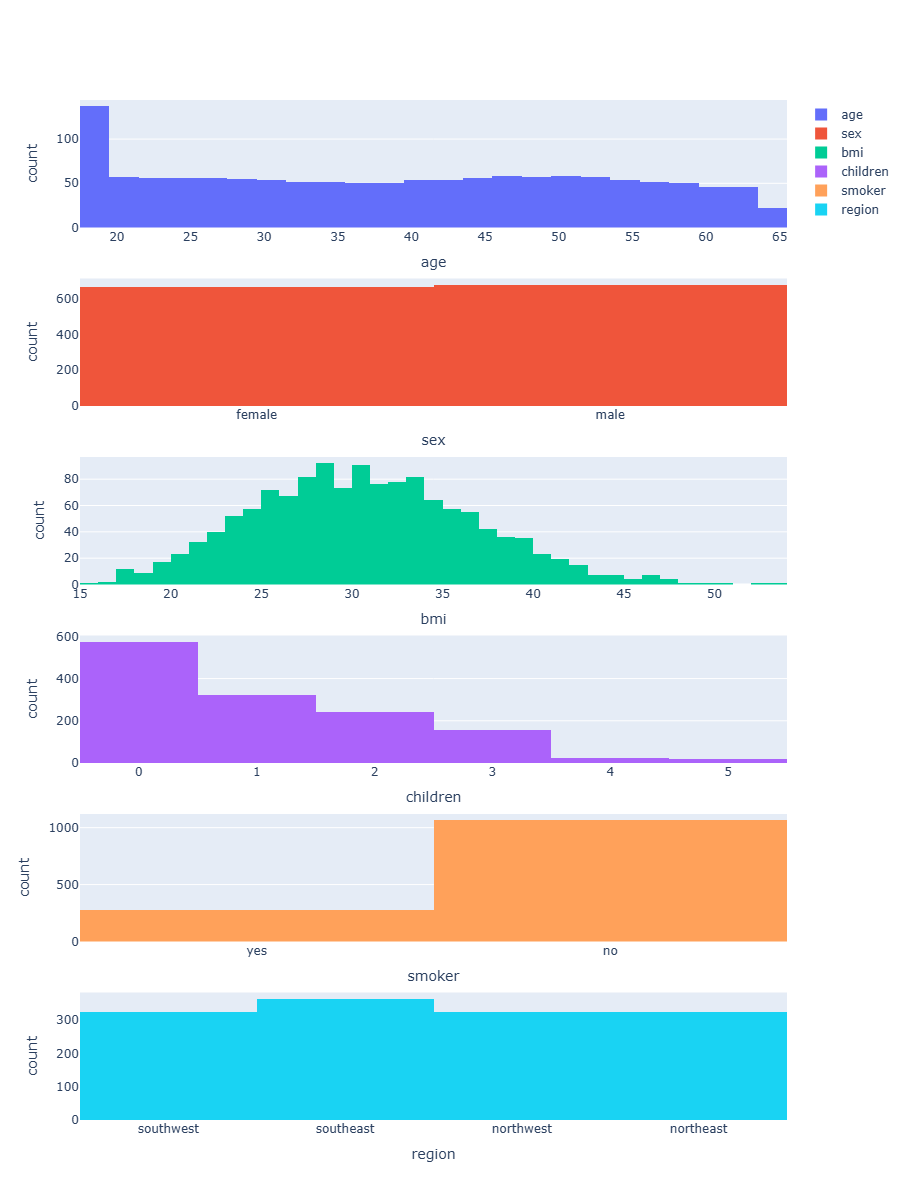

In [8]:
plot_histograms(X)

Points to note regarding the distribution of each feature:

* `age` - Approximately uniformly distributed.
* `sex` - Approximately equal volume in each category.
* `bmi` - Approximately normally distributed.
* `children` - Right skewed (i.e. higher volume in lower range).
* `smoker` - Significantly more volume in the `no` category vs the `yes` category.
* `region` - Approximately equal volume in each category.

We can also observe the distribution of the target:

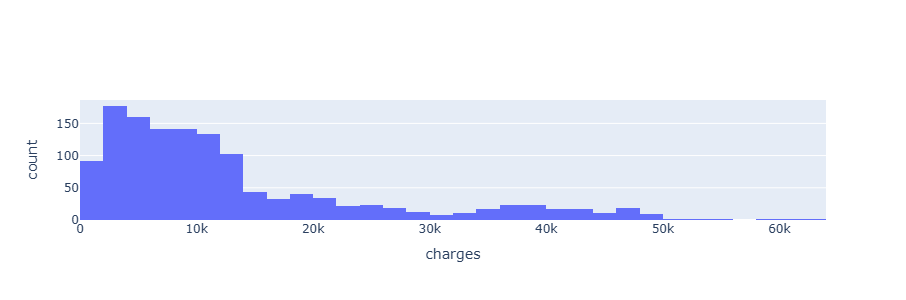

In [9]:
plot_histograms(pd.DataFrame(y), height=300)

The distribution is right skewed (i.e. higher volume in the lower range).

### **Univariate analysis (with respect to the target)**

Let's now apply univariate analysis with respect to the target. This means that we take each feature and see how it relates to the target.

The way in which we do this depends on whether the feature is numeric or categorical. For numeric features, we'll use a scatterplot; for categorical features, we'll use boxplots.

#### Numeric features

In [10]:
def plot_univariate_numeric(X,y):
    from plotly.subplots import make_subplots
    import plotly.graph_objects as go
    fig = make_subplots(rows=X.shape[1], cols=1)
    for i, col in enumerate(X.columns):
        fig.add_trace(
            go.Scatter(
                x=X[col],
                y=y,
                name=col,
                mode='markers'
            ),
            row=i+1,
            col=1
        )

        fig.update_xaxes(
            title_text=col,
            row=i+1,
            col=1
        )

        fig.update_yaxes(
            title_text='charges',
            row=i+1,
            col=1
        )

    fig.update_layout(
        height=1200
        )

    fig.show()

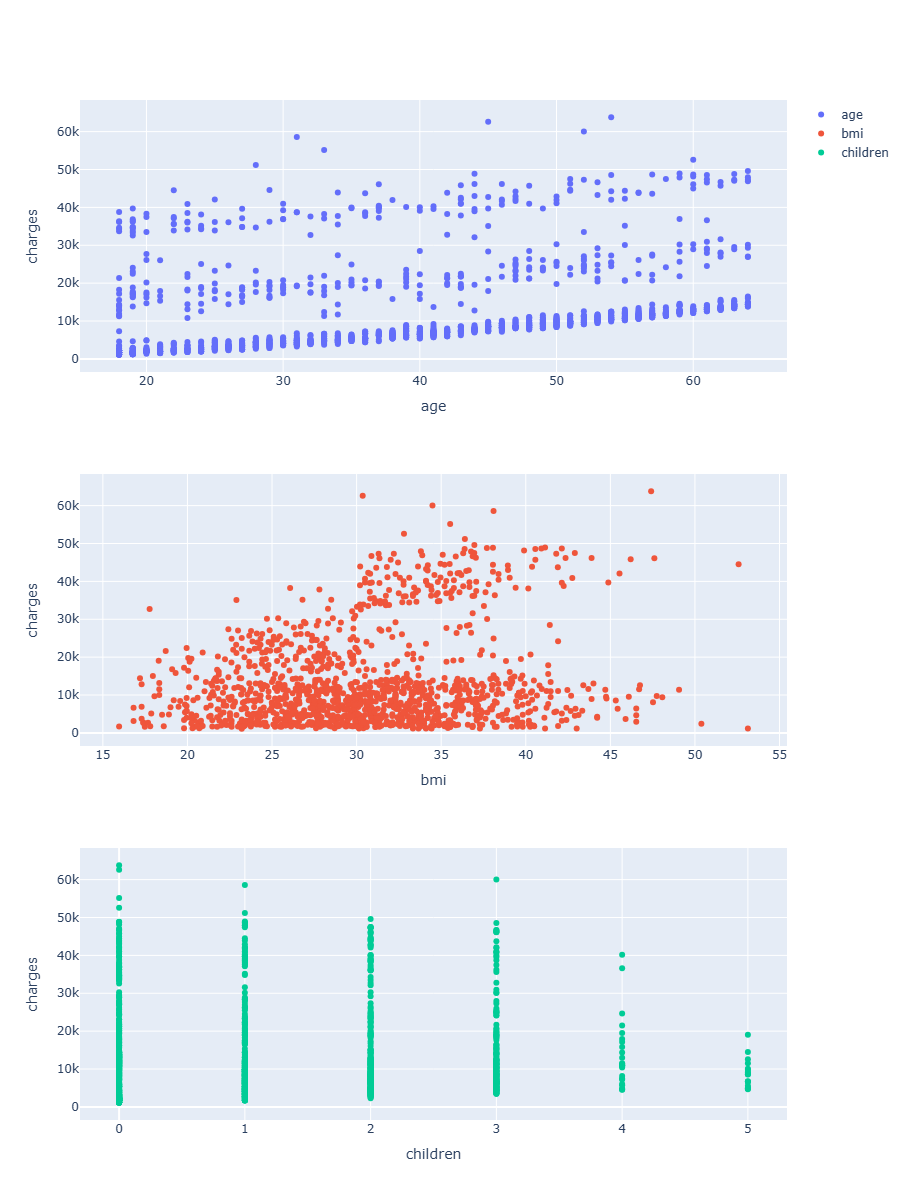

In [11]:
plot_univariate_numeric(
    X.select_dtypes(include=np.number),
    y
)

Points to note regarding each feature:

* `age` - As `age` increases, `charges` also tends to increase (although there is a large variance in `charges` for a given `age`).
* `bmi` - There is no clear relationship, although there seems to be a group of individuals with `bmi` > 30 that have `charges` > 30k. This group may become more apparent when we carry out our bivariate analysis later.
* `children` - No clear relationship (although `charges` seems to decrease as `children` increases). **Since there are only 6 unique values for this feature, let's try treating it as a categorical feature for the purposes of univariate analysis.**

#### Categorical features

In [12]:
def plot_univariate_categorical(X,y):
    from plotly.subplots import make_subplots
    import plotly.graph_objects as go
    fig = make_subplots(rows=X.shape[1], cols=1)
    for i, col in enumerate(X.columns):
        fig.add_trace(
            go.Scatter(
                x=X[col],
                y=y,
                name=col,
                mode='markers'
            ),
            row=i+1,
            col=1
        )

        fig.update_xaxes(
            title_text=col,
            row=i+1,
            col=1
        )
    fig.update_layout(
            height=1200
    )
    fig.show()
        

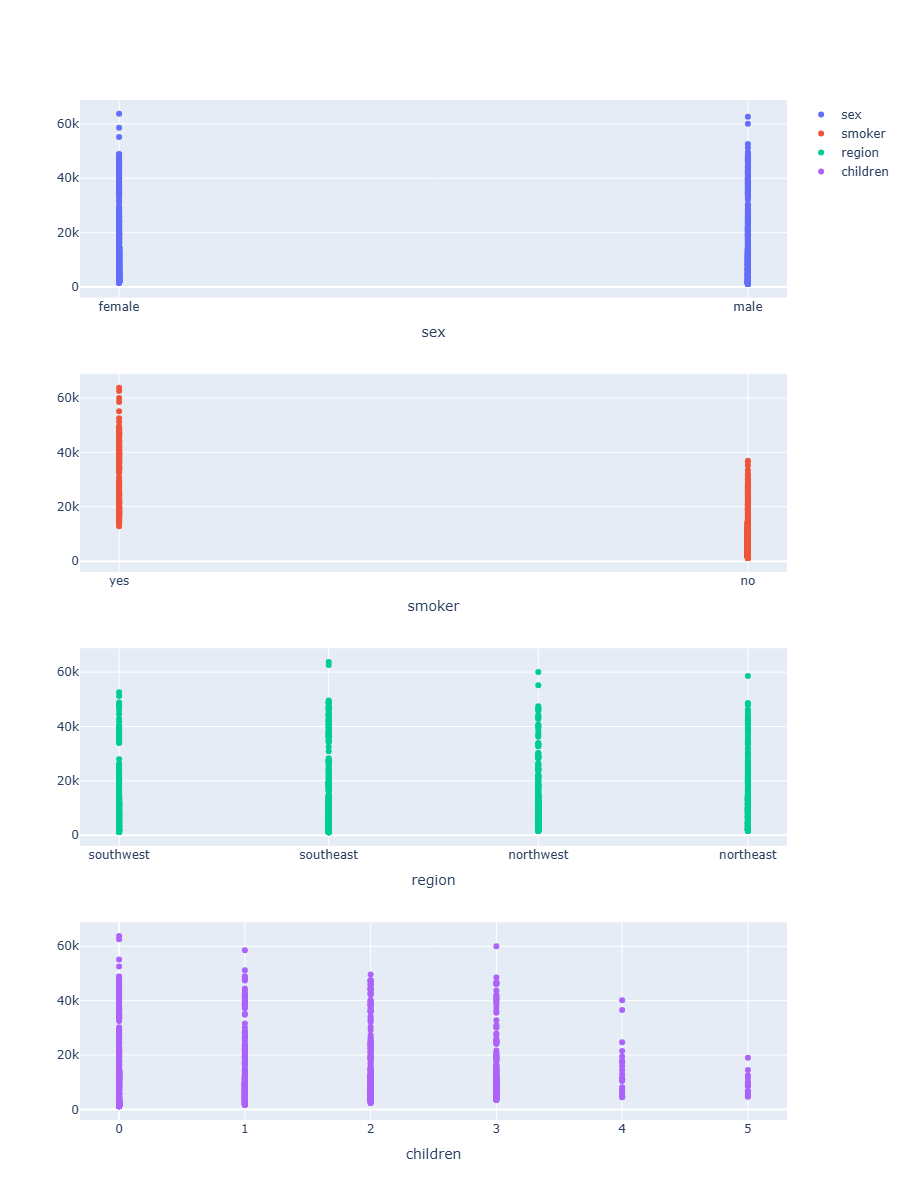

In [13]:
plot_univariate_categorical(
    X[['sex','smoker','region','children']],
    y
)

Points to note regarding each feature:

* `sex` - No significant differences in `charges` between the categories.
* `smoker` - `charges` for `smoker` == 'yes' are generally much higher than when `smoker` == 'no'.
* `region` - No significant differences in `charges` between the categories.
* `children` - No significant differences in `charges` between the categories (`children` >= 4 are skewed towards lower `charges`, but this is likely due to the low volumes in those categories - see the **Distributions** section).

### **Bivariate analysis (with respect to the target)**

Let's now apply bivariate analysis with respect to the target. This means that we take pairs of features and see how they relate to the target.

The way in which we do this depends on whether the feature pairs are all numeric, all categorical or a mixture of categoric and numeric. For all numeric pairs, we'll use a heatmap; for all categorical pairs, we'll use boxplots; for categorical-numeric pairs, we'll use a scatterplot. 

#### **Numeric pairs**

##### **Correlation Heatmap**
 
A correlation heatmap is a heatmap that depicts a two-dimensional correlation matrix between two discrete dimensions, with colored pixels representing data on a color scale. The values of the first dimension are displayed as rows in the table, while the values of the second dimension appear as columns. The cell's hue is proportional to the number of measurements corresponding to the dimensional value.
 
This makes correlation heatmaps great for data analysis since they show differences and variances in the same data while making patterns clearly accessible. A correlation heatmap, like a standard heatmap, is aided by a color bar to make data more legible and understandable.

In [14]:
def plot_heatmap(X,y,bins=10):
    import pandas as pd
    import plotly.express as px
    from itertools import combinations, product
    data=pd.concat([X,y], axis=1)
    for num_col in X.select_dtypes(include=np.number):
        
        if X[num_col].nunique() < bins:
            continue
        else:
            data[num_col] = pd.cut(data[num_col], bins= bins)
    col_pairs = list ( combinations(X.columns,2))
    for col1,col2 in col_pairs:
        col_pair_y_mean = data.groupby(
            [col1,col2]
        )[y.name].mean().reset_index()
        col_pair_y_mean = col_pair_y_mean.pivot (
            index = col1, columns=col2, values=y.name
        )
        col_pair_y_mean.sort_index(ascending= False, inplace= True)
        col_pair_y_mean.index = col_pair_y_mean.index.astype(str)
        col_pair_y_mean.columns= col_pair_y_mean.columns.astype(str)
        fig= px.imshow(col_pair_y_mean)
        fig.show()
    

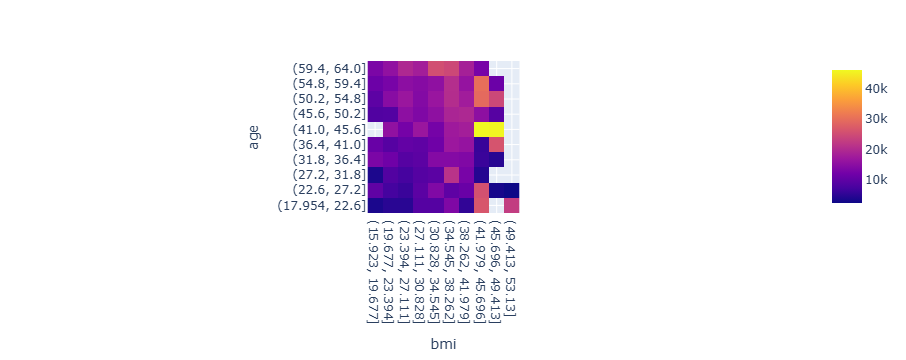

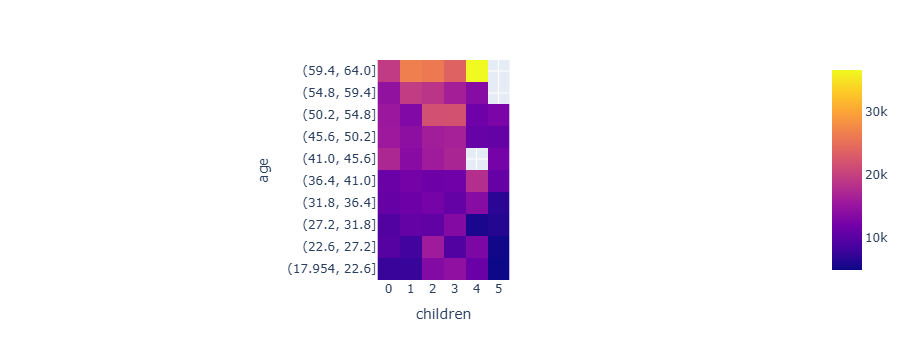

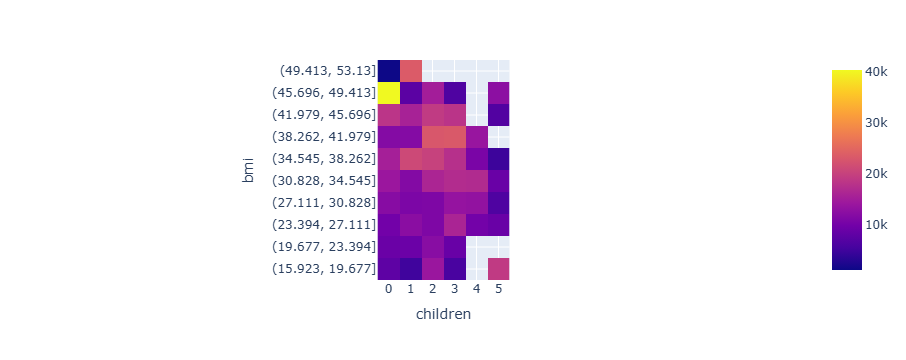

In [15]:
plot_heatmap(
    X[['age','bmi','children']],
       y,
       bins=10
    )

No additional insight can be gained from these plots that we haven't already obtained from the univariate analysis.

#### **Categorical pairs**

**Box Plots**


A box and whisker plot, often known as a box plot, shows a five-number summary of a collection of data. The minimum, first quartile, median, third quartile, and maximum are the five-number summary. A box plot is created by drawing a box from the first to third quartiles which is the Inter Quartile Range (IQR). At the median, a vertical line runs through the box.

In [16]:
def plot_paired_boxplots(X,y):
    from itertools import combinations
    from plotly.subplots import make_subplots
    import plotly.graph_objects as go
    import pandas as pd
    col_pairs=list(combinations(X.columns,2))
    fig=make_subplots(rows=len(col_pairs),cols=1)
    for i, ( col1,col2) in enumerate(col_pairs):
        paired_cat=col1 + '=' + X[col1] + ',' + col2 + '=' + X[col2]
        fig.add_trace ( 
            go.Box(
                x=paired_cat,
                y=y,
                name=f'{col1} & {col2}'
            ),
            row=i+1,
            col=1
        )
        fig.update_xaxes(
            title_text=f'{col1} & {col2}',
            row=i+1,
            col=1,
            categoryorder='array',
            categoryarray=sorted(paired_cat.unique())
        )
        fig.update_yaxes(
            title_text='charges',
            row=i+1,
            col=1
        )
    fig.update_layout(
            height=1800
    )
    fig.show()
    

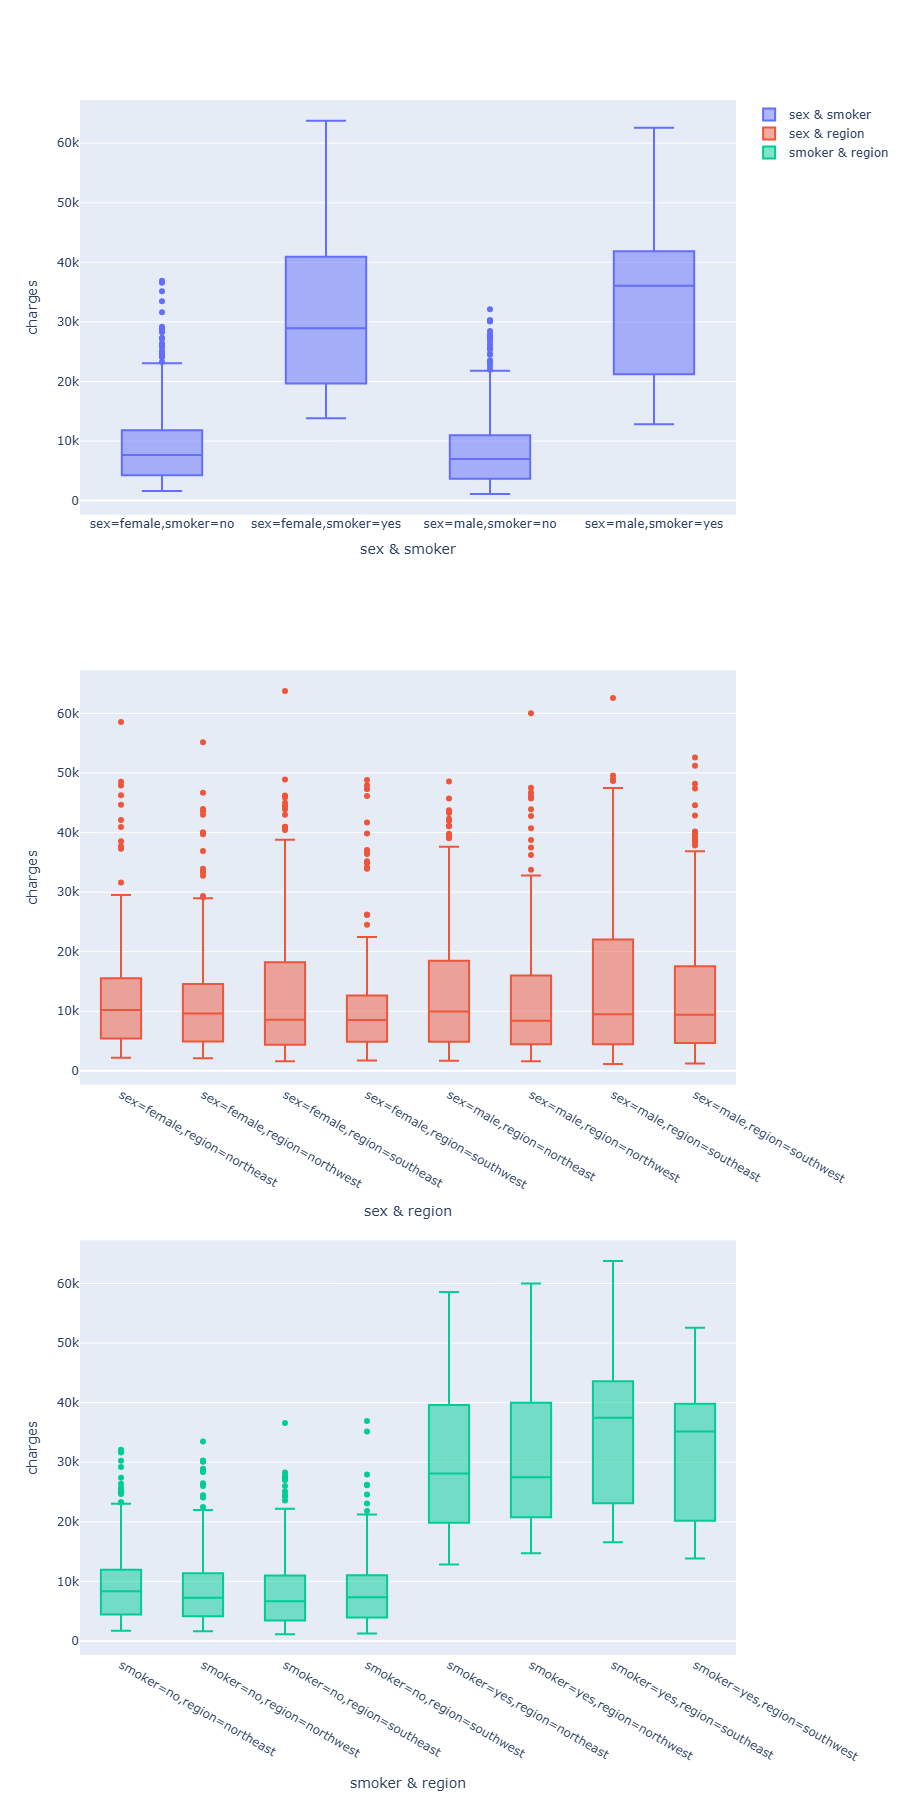

In [17]:
plot_paired_boxplots(
    X[['sex','smoker','region']],
    y
)

Points to note regarding these feature pairs:

* `sex`-`smoker` - The median `charges` is higher for males who smoke compared to females who smoke (36k vs 29k)
* `smoker`-`region` - The median `charges` is higher for smokers in the southwest and southeast vs the northeast and northwest (35k and 37k vs 28k and 27k)

#### **Numeric-categorical pairs**

In [18]:
def plot_paired_scatterplots(X,y):
    import pandas as pd
    import numpy as np
    from itertools import product
    from plotly.subplots import make_subplots
    import plotly.graph_objects as go
    data=pd.concat([X,y],axis=1)
    num_cols=X.select_dtypes(np.number).columns
    cat_cols=X.select_dtypes(object).columns
    col_pairs=list(product(num_cols,cat_cols))
    fig=make_subplots(rows=len(col_pairs), cols=1)
    j=1
    for i, (col1,col2) in enumerate(col_pairs):
        for col2_val in X[col2].unique():
            mask=X[col2]==col2_val
            X_=X[mask]
            y_=y[mask]
            fig.add_trace(
                go.Scatter(
                    x=X_[col1],
                    y=y_,
                    name=col2_val,
                    mode='markers',
                    legendgroup=j
                ),
                row=i+1,
                col=1
            )
        fig.update_xaxes(title_text=col1, row=i+1, col=1)
        fig.update_yaxes(title_text=y.name, row=i+1, col=1)
        j += 1
    fig.update_layout(
        height=4800,
        legend_tracegroupgap=485,
    )
    fig.show()
        

/tmp/ipykernel_3386/3210666677.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols=X.select_dtypes(object).columns


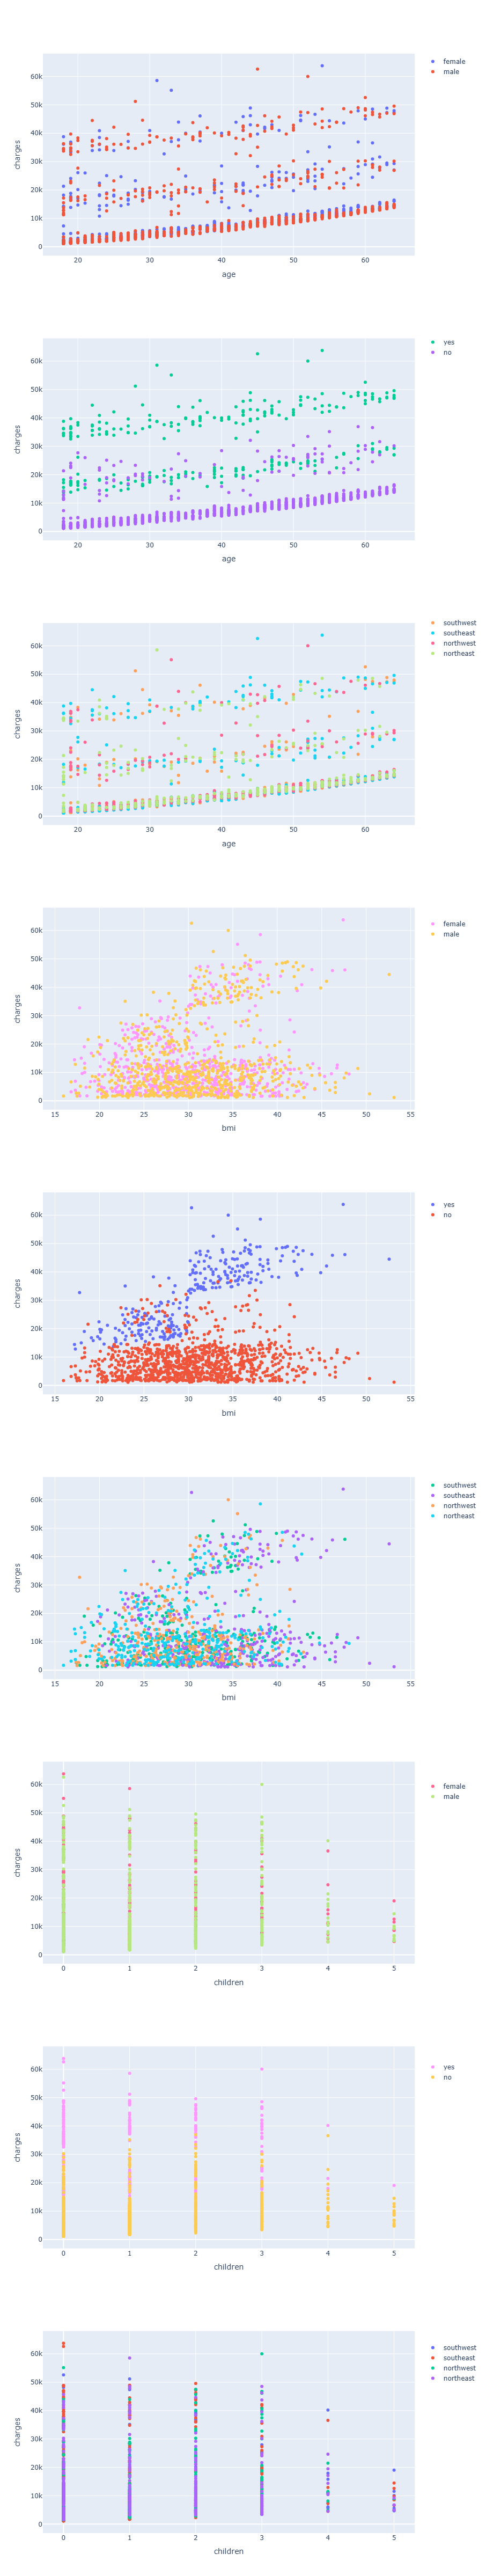

In [19]:
plot_paired_scatterplots(X,y)

There are two pieces of insight from these graphs:

* `age`-`smoker` - There is a group in the bottom left hand quadrant of the chart (where `age` < 50 and `smoker` = 'no') where all beneficiaries have health care costs below 10k (which is relatively small compared to the rest of the population).
* `bmi`-`smoker` - There is a group in the top right hand quadrant of the chart (where `bmi` > 30 and `smoker` = 'yes') where all beneficiaries have health care costs above 30k (which is relatively large compared to the rest of the population).

### **Collinearity (between features)**

Now let's look at collinearity (i.e correlation) between features.

The way in which we do this depends on whether the feature pairs are all numeric, all categorical or a mixture of categoric and numeric. For all numeric pairs, we'll use the **Pearson's correlation**; for all categorical pairs, we'll use a **$\chi^2$ test**; for categorical-numeric pairs, we'll use an **Analysis of Variance (ANOVA) test**. 

#### **Numeric features**

First, let's use a pairplot to see how each pair of numeric features relate to one another:

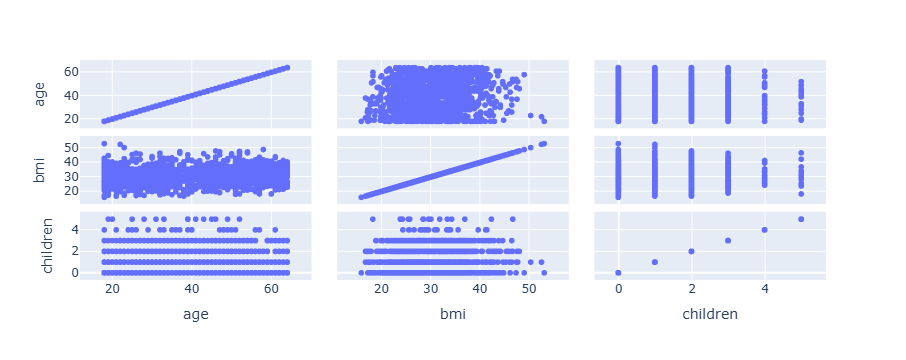

In [20]:
px.scatter_matrix(
    X.select_dtypes(include=np.number)
)

There doesn't look like there's much correlation between any of the numeric features. To be sure, let's calculate and plot the **Pearson's correlation matrix**:

**Correlation**

Correlation coefficient is used to measure the strength of relationship between two variables. It indicates that as the value of one variable changes the other variable changes in a specific direction with some magnitude. There are various ways to find correlation between two variables, one of which is Pearson correlation coefficient.
It measures the linear relationship between two continuous variables.
 
Let's say $x$ and $y$ are two continuous variables, the Pearson correlation coefficient between them can be found by the following formula.
 
 
$$r = \frac{ \sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y}) }{%
        \sqrt{\sum_{i=1}^{n}(x_i-\bar{x})^2}\sqrt{\sum_{i=1}^{n}(y_i-\bar{y})^2}}$$
 
where $x_i$ and $y_i$ represents the $i^{th}$ value of the variables.
The value of $r$ ranges between $-1$ and $+1$.
 
Their strength of relationship is measured by the absolute value of coefficient, whereas the sign of the coefficient indicates the direction of the relationship.
 



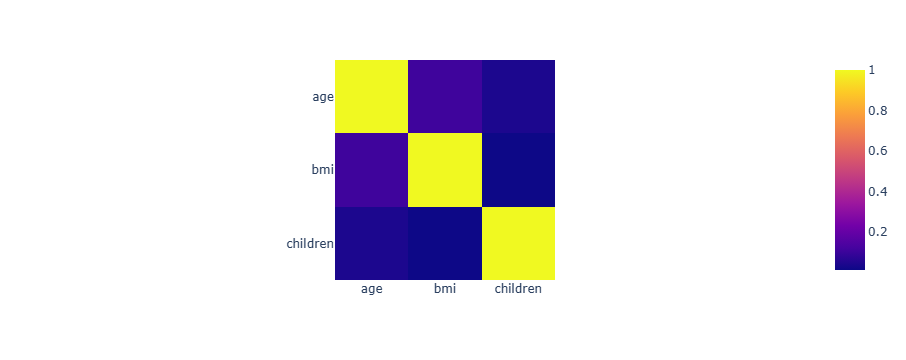

In [21]:
px.imshow(X.select_dtypes(include=np.number).corr())

This suggests there is very little correlation between the numeric features.

#### **Categorical features**

 **Chi Squared Test**

A sample's distribution of a categorical variable must frequently be compared to the distribution of a categorical variable in another sample.

The chi squared test of independence, often known as the chi squared test of association, is used to detect whether or not categorical variables are related. 

The data must meet the following requirements for this test:

* Categorical variables
* Sample size is relatively large
* Independent observations

The chi squared test is performed in the following steps:
* Find a "expected" number (E) for each observed number (0) in the table.

$$χ^2  = \frac{∑(O_i – E_i)^2}{E_i}$$

* A chi-square test will provide us with a p-value. The p-value indicates whether or not our test results are significant.

However, in order to do a chi-square test and calculate the p-value, we need two pieces of information:

* Degrees of freedom. That is simply the number of categories minus one.

* Significance Level. The standard alpha level is 0.05 (5%), but alternative values such as 0.01 or 0.10 are possible.

* The following are the different values of p that indicate different hypothesis interpretations:

* P = 0.05; Hypothesis is rejected
* P > 0.05; Acceptance of Hypothesis

Watch the videos, [Degrees of Freedom Part 1](https://www.projectpro.io/project/hackerday-project/project-title/piecewise%20spline%20regression%20project#sub-hackerday-video-18) and [Degrees of Freedom Part 2](https://www.projectpro.io/project/hackerday-project/project-title/piecewise%20spline%20regression%20project#sub-hackerday-video-19) to understand the basics of Degrees of Freedom and their interpretation.





For categorical features, we'll use a Chi Squared ($\chi^2$) test to observe whether each categorical feature pair is correlated.

First, we calculate the $\chi^2$ values, p-values and degrees of freedom:

In [22]:
def chi2(X,correction=True):
    from itertools import combinations, product
    import pandas as pd
    import numpy as np
    import scipy.stats as stats
    col_pairs=list(combinations(X.columns,2))
    results_list=[]
    for col1,col2 in col_pairs:
        contigency=pd.crosstab(
            X[col1],
            X[col2]
        )
        chi2,p_val,dof,exp_freq=stats.chi2_contingency(
            contigency.values, correction=correction
        )
        results_list.append([col1,col2,chi2,p_val,dof])
    results=pd.DataFrame(
        results_list,
        columns=[
            'column1','column2','chi_squared','p_value','dof' ]
    )
    return results

In [23]:
X_chi2=chi2(X.select_dtypes(object))

/tmp/ipykernel_3386/1413270079.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X_chi2=chi2(X.select_dtypes(object))


In [24]:
X_chi2

,column1,column2,chi_squared,p_value,dof
0,sex,smoker,7.392911,0.006548,1
1,sex,region,0.435137,0.932892,3
2,smoker,region,7.343478,0.061720,3


Since there are only three different categorical feature pairs, we won't plot the results.

We can use the p-value (which is derived from the $\chi^2$ result and the degrees of freedom) to test how likely the observed distribution (for each feature pair) happened due to chance. For example, a p-value of 0.5 means that there is a 50% probability of observing the distribution by chance. 

A threshold of < 0.05 is widely accepted for rejecting the null-hypothesis (that the features are independent) since this means that there is only a 5% probability of observing the distribution by chance.

The only feature pair with a p-value less than this threshold is `sex` and `smoker`, which means it's likely that these features are correlated:

In [58]:
X_chi2[X_chi2['p_value'] < 0.05]

,column1,column2,chi_squared,p_value,dof
0,sex,smoker,7.392911,0.006548,1


#### **Numeric-categorical feature pairs**

### **Analysis of Variance (ANOVA) Test**

For numeric-categorical feature pairs, we use an **ANOVA** (Analysis of Variance) test. ANOVA is a statistical hypothesis test used to evaluate the differences between group means by analyzing their variances. It helps us understand if there are statistically significant differences between the means of independent groups.

* **Requirement:** It requires at least one continuous (numeric) variable and one categorical variable that splits the data into comparison groups.
* **Mechanism:** It compares the variance *between* group means to the variance *within* the groups. This determines whether the groups are part of a larger, single population or if they represent distinct populations with different means.
* **Hypotheses:**
  * **Null Hypothesis ($H_0$):** All groups have the same mean.
  * **Alternate Hypothesis ($H_a$):** At least one group has a different mean.

First, we calculate the $F$-values (the ratio of the between- and within-group mean squares) and $p$-values:


In [62]:
def anova(X):
    from itertools import combinations, product
    import pandas as pd
    import numpy as np
    import scipy.stats as stats
    num_cols = X.select_dtypes(np.number).columns
    cat_cols = X.select_dtypes(object).columns
    col_pairs = list(product(num_cols, cat_cols))
    results_list = []
    for num_col, cat_col in col_pairs:
        X_filtered_list = []
        cat_values = X[cat_col].unique()
        for cat_value in cat_values:
            X_filtered_list.append(X[X[cat_col] == cat_value][num_col].values)
        f_stat, p_val = stats.f_oneway(*X_filtered_list)
        results_list.append([num_col, cat_col, f_stat, p_val])
    results = pd.DataFrame(
        results_list,
        columns=[
            'num_column', 'cat_column', 'f_stat', 'p_value'
        ]
    )
    return results


In [63]:
X_anova = anova(X)

/tmp/ipykernel_3386/21571650.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(object).columns


In [64]:
X_anova

,num_column,cat_column,f_stat,p_value
0,age,sex,0.581369,4.459107e-01
1,age,smoker,0.836777,3.604853e-01
2,age,region,0.079782,9.709891e-01
3,bmi,sex,2.878970,8.997637e-02
4,bmi,smoker,0.018792,8.909850e-01
5,bmi,region,39.495057,1.881839e-24
6,children,sex,0.393659,5.304898e-01
7,children,smoker,0.078664,7.791596e-01
8,children,region,0.717493,5.415543e-01


Similar to the $\chi^2$ test above, we can use the p-value to test how likely the observed distribution (for each feature pair) happened due to chance. We will again apply the threshold of < 0.05 isfor rejecting the null-hypothesis (that the features are independent).

The only feature pair with a p-value less than this threshold is `bmi` and `region`, which means it's likely that these features are correlate
d:

In [65]:
X_anova[X_anova['p_value'] < 0.05]

,num_column,cat_column,f_stat,p_value
5,bmi,region,39.495057,1.881839e-24


### **Correlation (with respect to the target)**

Now we will calculate the correlation between the features and the target. This will be useful when it comes to building our baseline linear model.

We can apply the same techniques that we used when calculating collinearity between features.

#### **Numeric features (with respect to the target)**

Here, we'll calculate the Pearson's Correlation between each numeric feature and the target:

In [66]:
def plot_pearson_wrt_target(X,y):
    
    import pandas as pd
    import numpy as np
    import plotly.express as px
    data=pd.concat([X,y],axis=1)
    data_corr=data.select_dtypes(np.number).corr()
    data_corr.index.name='features'
    data_corr=data_corr.reset_index()
    data_corr=data_corr[data_corr['features'] != y.name]
    fig=px.bar(
        data_frame=data_corr.reset_index(),
        x='features',
        y='charges'
    )
    fig.update_yaxes(title='correlation')
    fig.show()

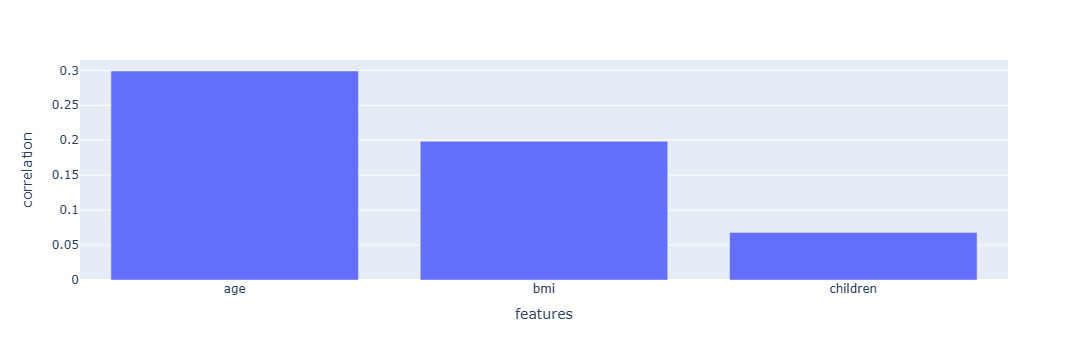

In [67]:
plot_pearson_wrt_target(X, y)

The `children` feature has a very low correlation with respect to the target.

#### **Categorical features (with respect to the target)**

Here, we'll apply the ANOVA test. Note that since we're only interested in comparing each categorical feature to the target, we filter out the results of all other numeric features:

In [68]:
data_anova=anova(data)
anova_wrt_target=data_anova[data_anova['num_column']=='charges']

/tmp/ipykernel_3386/21571650.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(object).columns


In [69]:
anova_wrt_target

,num_column,cat_column,f_stat,p_value
9,charges,sex,4.399702,3.613272e-02
10,charges,smoker,2177.614868,8.271436e-283
11,charges,region,2.969627,3.089336e-02


All p-values are < 0.05, which means that the differences observed in the `charges` column when comparing the categories within a categorical variable are statistically significant. **Note however that this doesn't measure the magnitude of the differences observed.**

## **Build and Evaluate a Baseline Linear Model**

**Objective:**
Establish a benchmark score using a simple Linear Regression model to evaluate future model improvements.

**Key Steps:**
1. **Feature Selection:** Filter and use only numeric features for the baseline model.
2. **Data Splitting:** Divide the dataset into Training (80%) and Testing (20%) sets to validate performance.
3. **Model Training:** Fit a `LinearRegression` model from `scikit-learn` on the training data.
4. **Evaluation:** Assess the model using $R^2$ and Adjusted $R^2$ to see how well features explain the variance in insurance `charges`.

### **Errors in Regression**

No regression model is perfect; there will always be a difference between the actual values ($y$) and predicted values ($\hat{y}$), known as **residuals (errors)**. We use four main metrics to evaluate these errors:

---

#### **1. MAE (Mean Absolute Error)**
* **What it is:** The average of the absolute differences between actual and predicted values.
* **Formula:** $$MAE = \frac{1}{n}\sum_{i=1}^{n}|y-\hat y|$$
* **Key Feature:** Robust to outliers. Each error contributes proportionally.

#### **2. MSE (Mean Squared Error)**
* **What it is:** The average of the squared differences between actual and predicted values.
* **Formula:** $$MSE= \frac{1}{n}\sum_{i=1}^{n}(y-\hat y)^2$$
* **Key Feature:** **Punishes large errors/outliers heavily** because errors are squared. Units are squared, making it hard to interpret directly.

#### **3. RMSE (Root Mean Squared Error)**
* **What it is:** The square root of MSE.
* **Formula:** $$RMSE= \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y-\hat y)^2}$$
* **Key Feature:** Keeps the same severe punishment for outliers as MSE, but brings the error scale **back to the original units** for easy interpretation.

#### **4. MAPE (Mean Absolute Percentage Error)**
* **What it is:** The percentage counterpart of MAE.
* **Formula:** $$MAPE= \frac{100\%}{n}\ \sum_{i=1}^{n}\left| \frac{y-\hat y}{y} \right|$$
* **Key Feature:** Extremely easy to understand for business use cases because it shows the error as a percentage. Robust to outliers.

### **Model Comparisons**

* $R^2$: The $R^2$ or the coefficient of determination is the proportion of the variance in the dependent variable that is explained from the independent variable(s). $R^2$ is expressed between 0 and 1 for the level of variance explained.
As we learned in the previous section, the ratio $\frac{SSE}{TSS}$ should be low for a robust model, this ratio signifies the error or unexplained variance by the independent variable(s).
Mathematically, $R^2$ or explained variance can be expressed as:
 
$$ R^2 = 1 - \frac{SSE}{TSS} $$
 
* Adjusted $R^2$: For linear models, adjusted $R^2$ is a corrected goodness-of-fit statistic. It determines the proportion of variance in the target field explained by the input or inputs.
$R^2$ tends to overestimate the goodness-of-fit of the linear regression. It always grows as the number of independent variables in the model grows.
It happens because we tend to deduct a large amount (due to multiple variables) to calculate error as the number of independent variables increases. Hence, the ratio $\frac{SSE}{TSS}$ is even lower than it should be and  $R^2$ seems to be high but it might not be an appropriate model for production data. It is adjusted to account for this overestimation. Considering N as the total sample size and p as the number of independent variables, adjusted $R^2$ can be expressed as:

$$ \text{Adjusted }  R^2 = 1 - \frac{(1 - R^2)(N - 1)}{N - p - 1} $$

### **Data preprocessing**

It's always best practise to split your dataset into a training set (which we use for training any data processing steps and the model itself) and a test set (which we only use for model evaluation). 

**We can then be more confident in the performance of our model on unseen data.**

In [26]:
def split_data(data,target,size,randomstate):

    X=data.drop(target,axis=1)
    y=data[target]
    X_train,X_test,y_train,y_test=train_test_split(
        X,
        y,
        test_size=size,
        random_state=randomstate
    )
    return X_train,X_test,y_train,y_test

In [27]:
X_train,X_test,y_train,y_test= train_test_split(
    X,
    y,
    test_size=0.33,
    random_state=42
)

#### **Remove unnecessary columns**

After our EDA, we concluded that the `children` feature is not strongly correlated to `charges`. This violates Assumption 2 of a linear regression model, so we should remove this feature from our training set. 

Also, our $\chi^2$ test suggested the `sex` feature is correlated to the `smoker` feature, and our ANOVA test suggested the `region` feature is correlated to the `bmi` feature. This violates Assumption 3 of a linear regression model, so we should remove these features from our training set. We will remove the `sex` and `region` features, since these had weaker predictive power with respect to the target.

After our EDA, we concluded that the `children` feature is not strongly correlated to `charges`. This violates Assumption 2 of a linear regression model, so we should remove this feature from our training set. 

Also, our $\chi^2$ test suggested the `sex` feature is correlated to the `smoker` feature, and our ANOVA test suggested the `region` feature is correlated to the `bmi` feature. This violates Assumption 3 of a linear regression model, so we should remove these features from our training set. We will remove the `sex` and `region` features, since these had weaker predictive power with respect to the target.

In [28]:
cols_to_drop = [
    'children',
    'region',
    'sex'
]
X_train.drop(cols_to_drop, axis=1, inplace=True)
X_test.drop(cols_to_drop, axis=1, inplace=True)

#### **Encoding**

 **One - Hot Encoding**

Most Machine Learning algorithms are unable to deal with categorical data and must be transformed to numerical data.
What are our options for converting categorical data to numerical data? Should we number the labels? For example, red represents 0 and blue represents 1. It will cause a bias in the model since the model will consider blue to be superior to red.

To address this, we use a categorical data encoding approach known as one hot encoding. In this method, we build a new feature for each label and assign it a value of 1. For example, if blue is present, it is marked as 1, else it is 0.

Now, we need to encode our categorical features - this means transforming them into numeric features so the model can interpret them. 

There are many encoding methods, but in this example we'll use One Hot Encoding, which creates a boolean column for each category in each categorical feature.



##### **Did you know - I**

Notice that we fit the encoder on the training set, but only transform the test set. This ensures that only the categories found in the training set are one hot encoded (which prevents **data leakage** - when information outside the training set is used to build the model). 

A supervised algorithm's goal is to generate predictions about data that the algorithm has never seen before. As a result, while training an algorithm to predict validation and test splits, practitioners must ensure that the algorithm does not obtain access to knowledge about such splits inadvertently. By encoding the labels all at once before dividing, you indirectly indicate that you already know what are the possible classes or numeric ranges we are going to see in the future. Depending on the definition, this could be defined as data leaking, because you can deduce information that isn't in the training set.

Notice we will use fit and transform on the training set and just transform on the test set which essentially means that the one hot encoder object is trained or fitted by seeing the values of just the training set.

In [29]:
ohe=OneHotEncoder(use_cat_names=True)
X_train=ohe.fit_transform(X_train)
X_test= ohe.transform(X_test)

Since the `smoker` feature only has two categories, we can drop the encoded `smoker_no` column, since it doesn't provide any additional information:

In [30]:
cols_to_drop = ['smoker_no']
X_train.drop(cols_to_drop, axis=1, inplace=True)
X_test.drop(cols_to_drop, axis=1, inplace=True)

#### **Transformation of the target**

We saw in the **EDA** section that the target was not normally distributed. A model trained using this target will likely produce residuals that **do not** have the same variance across values of the target (i.e. assumption 5 of the linear regression model will be violated).

Power transforms are a family of parametric, monotonic transformations that are applied to make data more Gaussian-like. This is useful for modeling issues related to heteroscedasticity (non-constant variance), or other situations where normality is desired.

Currently, PowerTransformer supports the Box-Cox transform and the Yeo-Johnson transform.

So we'll use the **Yeo-Johnson** transformation to ensure our target is more normally distributed:

In [33]:
pt = PowerTransformer(method='yeo-johnson')
y_train_t = pt.fit_transform(y_train.values.reshape(-1, 1))[:, 0]
y_test_t = pt.transform(y_test.values.reshape(-1, 1))[:, 0]

Now let's quickly check whether this has had the desired effect (on both training and test sets):

<Axes: >

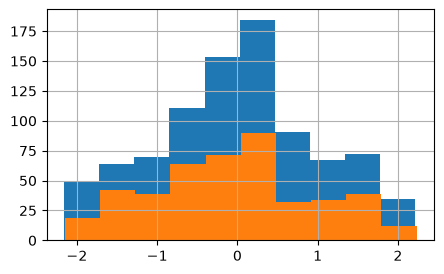

In [34]:
pd.Series(y_train_t).hist(figsize=(5,3))
pd.Series(y_test_t).hist(figsize=(5,3))

### **Model training**

In [35]:
sample_weight= y_train/ y_train.min()

Finally, we can train our linear regression model by passing it our training set and sample weights:

In [36]:
lr=LinearRegression()
lr.fit(
    X_train,
    y_train_t,
    sample_weight=sample_weight
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[0.02,0.03,1.38]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['age','bmi','smoker_yes']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.527
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


### **Model evaluation**

Now that we've trained our model, we can use it to generate predictions on both our training and test sets:

In [38]:
y_pred_train=lr.predict(X_train)
y_pred_test=lr.predict(X_test)

Remember that the model was trained based on a transformed version of the target. Therefore we need to perform the inverse **Yeo-Johnson** transform to convert the model predictions to the original format of the target:

In [40]:
y_pred_train=pt.inverse_transform(y_pred_train.reshape(-1,1))[:,0]
y_pred_test= pt.inverse_transform(y_pred_test.reshape(-1,1))[:,0]

With our predictions, we can evaluate our model:

In [44]:
def calc_model_performance(y_true,y_pred):
    from sklearn.metrics import root_mean_squared_error,mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
    results={}
    results['Root Mean Squared Error'] = root_mean_squared_error (
        y_true,y_pred
    )
    results['Mean Squared Error'] = mean_squared_error(y_true,y_pred)
    results['Mean Absolute Error']= mean_absolute_error(y_true,y_pred)
    results['Mean Absolute Percentage Error'] = mean_absolute_percentage_error (
        y_true,y_pred
    )
    results [ 'R Squared'] = r2_score(y_true,y_pred)
    return results

In [45]:
base_perf_train= calc_model_performance(y_train,y_pred_train)

In [46]:
base_perf_train

{'Root Mean Squared Error': 5964.030078582214,
 'Mean Squared Error': 35569654.778233364,
 'Mean Absolute Error': 4583.192097982616,
 'Mean Absolute Percentage Error': 0.7487185010627793,
 'R Squared': 0.7572131565843472}

In [47]:
base_perf_test=calc_model_performance(y_test,y_pred_test)

In [48]:
base_perf_test

{'Root Mean Squared Error': 5752.47740759071,
 'Mean Squared Error': 33090996.32484153,
 'Mean Absolute Error': 4534.422666801508,
 'Mean Absolute Percentage Error': 0.7565371597175806,
 'R Squared': 0.7741917225233025}

**So our evaluation metric for the model (RMSE) is ~5964 on the training set and ~5752 on the test set.**

### **Check normality of residuals**

We can check the normality of residuals using a QQ (quantile-quantile) plot. This plots the value of each actual quantile (from the data) vs the theoretical quantile (assuming a normal distribution). If the data is perfectly normally distributed, you'd expect the datapoints to lie on the line.

We'll also use a histogram as a more interpretable visualisation of the residuals.

In [53]:
residuals_train=y_train-y_pred_train
residuals_test=y_test-y_pred_test

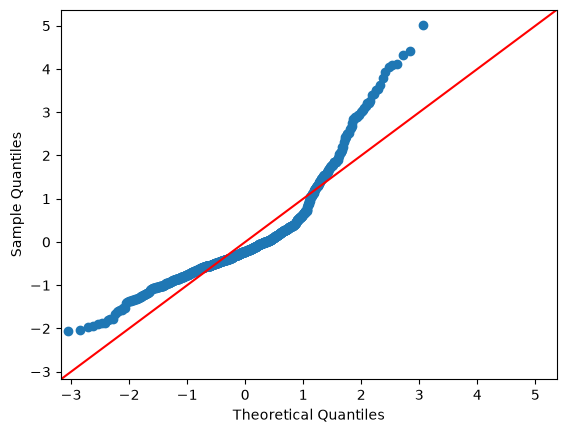

In [54]:
fig=sm.qqplot(
    residuals_train,
    fit=True,
    line='45'
)

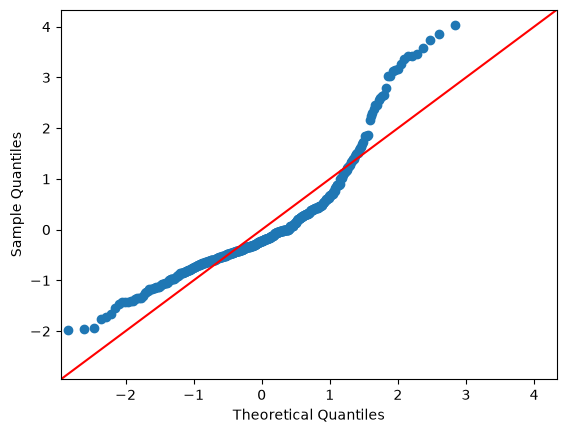

In [55]:
fig=sm.qqplot(
    residuals_test,
    fit=True,
    line='45'
)

Our residuals are not perfectly normally distributed, but are pretty close!

### **Check homoscedasticity**

We can check for homoscedasticity using a scatterplot, where the target is shown along the x-axis and the residuals are shown along the y-axis. We would expect the datapoints to be equally distributed across the y-axis as x (i.e. the target value) increases:

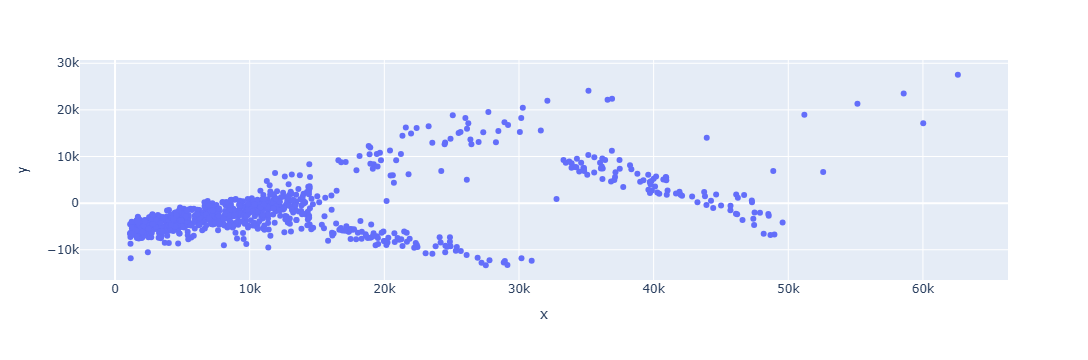

In [56]:
px.scatter(x=y_train,y=residuals_train)

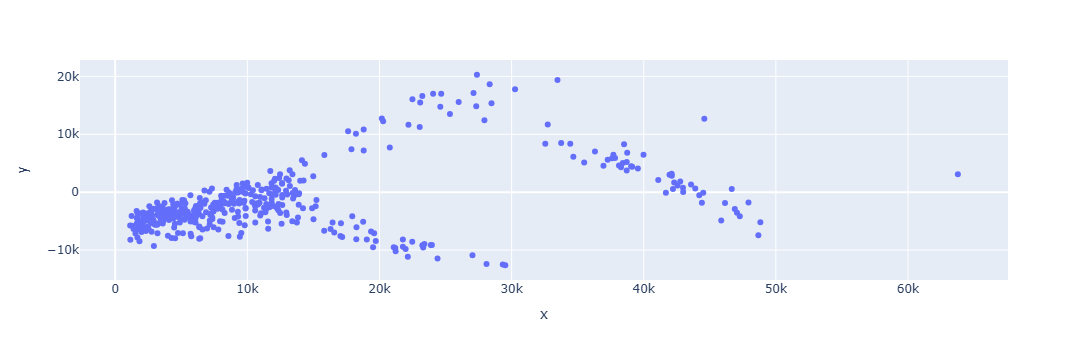

In [57]:
px.scatter(x=y_test, y=residuals_test)

Our model exhibits significant heteroscedasticity (i.e. the variance of the residuals is not homogeneous with respect to the target). Since this is a baseline model, we will not spend additional time attempting to improve this.

## **Improve on the baseline linear model**

Now let's try to improve upon our linear regression model by training a non-linear model. Here, non-linear refers to the fact that the model can learn non-linear relationships from the data.

### 1. Decision Trees (CART)
* **Concept:** A versatile supervised learning algorithm used for both regression and classification. In simple terms, it operates as a sequential series of nested `if-else` statements.
* **Structure:** It builds a tree-like flowchart starting from a **Root Node** at the top, splitting the data based on feature conditions, and concluding at the **Leaf Nodes** where final predictions are made.

### 2. Decision Trees and Overfitting
* **The Cause:** Tree generation relies on a **Greedy and Recursive algorithm**. It continuously splits data using a cost function (such as *Information Gain* or *Entropy*) to achieve the most homogeneous (pure) subsets possible.
* **The Issue:** Without restricting the maximum depth, the tree will grow overly complex—exhausting all features to capture noise and outliers in the training data. While it fits the training set perfectly, it fails to generalize, leading to high errors on new observations. Consequently, single decision trees are highly prone to **overfitting**.

### 3. Ensemble Learning: Bagging vs. Boosting
To mitigate the high variance and overfitting of single estimators, ensemble techniques combine multiple weak learners into a stronger predictor:

* **Bagging (Bootstrap Aggregating):** Trains multiple learners **in parallel** and averages their predictions to reduce overall variance (e.g., Random Forest).
* **Boosting:** Builds learners **sequentially (one after another)**, where each subsequent model specifically focuses on penalizing and correcting the errors made by the previous weak learners (e.g., XGBoost).

### 1. What is Boosting?
* **Concept:** Boosting is a general ensemble method—not a specific model—that converts a series of weak learners (e.g., shallow decision trees) into a strong predictor.
* **Mechanism:** Unlike Bagging, which trains models in parallel, Boosting operates **sequentially**. Each new model is trained to specifically correct the errors and faults made by its predecessors.

### 2. How it Works: Weight Redistribution
* In each iteration, the algorithm increases the weights of the misclassified or poorly predicted data points from the previous model. 
* This weight redistribution forces the subsequent learner to focus its performance on the hardest-to-predict samples.
* The process repeats until the data is perfectly predicted or a predefined maximum number of models is reached.

### 3. Bagging vs. Boosting (Bias-Variance Tradeoff)
* **Bagging:** Best suited for weak learners with **high variance and low bias** (like deep decision trees). It averages predictions to reduce overfitting.
* **Boosting:** Primarily targets learners with **low variance and high bias**. It sequentially combines them to reduce systematic error (bias).

### 4. Overfitting Risk & Mitigation
* Because Boosting continuously minimizes training errors by building upon previous models, it is **highly vulnerable to overfitting** (more so than Bagging).
* **Solutions:** To prevent the model from overfitting the training dataset, you must apply **hyperparameter tuning**, **regularization**, or restrict the maximum number of models (estimators) to a reasonable limit.

**Gradient Boosting**

The primary idea behind this technique is to develop models in a sequential manner, with each model attempting to reduce the mistakes of the previous model.The additive model, loss function, and a weak learner are the three fundamental components of Gradient Boosting.

The method provides a direct interpretation of boosting in terms of numerical optimization of the loss function using Gradient Descent. We employ Gradient Boosting Regressor when the target column is continuous, and Gradient Boosting Classifier when the task is a classification problem. The "Loss function" is the only difference between the two. The goal is to use gradient descent to reduce this loss function by adding weak learners. Because it is based on loss functions, for regression problems, Mean squared error (MSE) will be used, and  for classification problems, log-likelihood.

### **Introduction to a non-linear model - XGBoost**

### eXtreme Gradient Boosting (XGBoost) Architecture
XGBoost is an optimized, high-performance gradient-boosted decision tree algorithm widely used in machine learning competitions due to its speed and predictive power.

#### Step-by-Step Training Process for Regression:
1. **Initial Prediction:** Starts with a baseline prediction for all observations (usually $0.5$).
2. **Residual Calculation:** Computes the residuals (errors) by comparing the actual values to the current prediction.
3. **Build a Tree on Residuals:** Fits a decision tree to these residuals sequentially:
   * **Similarity Score ($S$):** Quantifies how homogeneous the residuals are in a node:
     $$S = \frac{(\Sigma R)^2}{N_R + \lambda}$$
     *(where $\lambda$ is the L2 regularization parameter to control overfitting).*
   * **Gain ($G$):** Evaluates if a split is beneficial by comparing the similarity of child nodes to the root node:
     $$G = S_{left} + S_{right} - S_{root}$$
     The algorithm greedily selects the split that maximizes this Gain.
   * **Stopping Criteria:** Repeats splits until constraints like maximum depth (`max_depth`) or minimum child weight (`min_child_weight`) are met.
4. **Tree Pruning:** Prunes the tree from the bottom up. A split is removed if its Gain ($G$) is less than a user-defined threshold $\gamma$ (`gamma`).
5. **Output Value ($O$):** Calculates the final prediction output for each leaf node:
   $$O = \frac{\Sigma R}{N_R + \lambda}$$
6. **Update Predictions:** Updates the overall prediction by adding the new tree's output, scaled by a learning rate $\eta$ (`learning_rate`):
   $$Pred_{new} = Pred_{init} + \eta \times Pred_{residual}$$
7. **Iteration:** Repeats the entire process (Steps 1–6) until a residual threshold is met or the maximum number of trees (`n_estimators`) is reached.

In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.33, 
    random_state=42
)

#### **Encoding**

In [72]:
ohe = OneHotEncoder(use_cat_names=True)
X_train = ohe.fit_transform(X_train)
X_test = ohe.transform(X_test)

### **Using Sklearn's `Pipeline` to optimise the model training process**

As mentioned in the introduction, the XGBoost algorithm has a number of parameters that can affect the predictive performance of the model. Rather than trying to optimise these parameters manually, we can leverage Sklearn's `Pipeline` class, along with Skopt's `BayesSearchCV` class, to optimise them automatically. 

We'll also use Recursive Feature Elimination (RFE) in this process to optimise the features that are used by the final XGBoost model. RFE works by fitting a model to all of the features, then calculating the feature importance. The least important feature is removed, then another model is trained using this dataset. This process is repeated until the desired number of features to select is reached.

Firstly, let's create our RFE and XGBoost regressor instances. We'll also use an XGBoost regressor as the model in our RFE.

In [73]:
rfe=RFE(estimator=XGBRegressor())
xgb=XGBRegressor()

Now we create our pipeline by specifying the list of sequential processes we want to run. The output of each step is passed to the next, with the final step being an estimator (i.e. model). In this case, we want to:

1. Apply feature selection (via RFE)
2. Train the XGBoost regressor

We do this by creating a list of tuples, where the first element of each tuple is a label for the step, and the second element is the class to run:

In [74]:
steps=[
    ('rfe', rfe),
    ('xgb',xgb)
]

Then we pass this to the `Pipeline` class:

In [75]:
pipe=Pipeline(steps)

When the `fit` method of the pipeline is called, it will pass the features and target to the RFE `fit_transform` method. The output of this will be passed to the `fit` method of the XGBoost regressor.

Now that we have our pipeline defined, we can set up our `BayesSearchCV` class to optimise the parameters of the pipeline. Firstly, we need to define the parameters we want to optimise and the space over which the `BayesSearchCV` should search. Note that since we're using a pipeline, we need to define the parameters related to each step by adding a prefix, which is the step's label and two underscores (e.g. `xgb__` for the XGBoost step):

In [76]:
num_features = X_train.shape[1]
search_spaces = {
    'rfe__n_features_to_select': Integer(1, num_features), # Num features returned by RFE
    'xgb__n_estimators': Integer(1, 500), # Num trees built by XGBoost
    'xgb__max_depth': Integer(2, 8), # Max depth of trees built by XGBoost
    'xgb__reg_lambda': Integer(1, 200), # Regularisation term (lambda) used in XGBoost
    'xgb__learning_rate': Real(0, 1), # Learning rate used in XGBoost
    'xgb__gamma': Real(0, 2000) # Gamma used in XGBoost
}

Once our search space for each parameter is defined, we pass this, along with our pipeline, to the `BayesSearchCV` class. This works by:
1. Creating a cross validation dataset of $n$ folds, where each fold has the same number of observations. For example, for 3 folds, the original dataset is randomly split into 3 subsets.
2. The following steps are then applied across all folds:
    1. Create a sub-training set comprising of $n$-1 folds and a sub-validation set comprising of the remaining fold. 
    2. Train the pipeline using a given set of parameters on the sub-training set.
    3. Use this trained pipeline to make predictions on the sub-validation set and calculate the scoring metric (i.e. the RMSE in this case).
3. Calculate the mean of the scoring metric across all sub-validation sets.
4. The algorithm then uses a bayesian approach to select the next set of parameters which will maximise the mean scoring metric across all sub-validation sets.
5. Steps 2-4 are repeated until a threshold is reached (see the `n_iter` parameter in the `BayesSearchCV` class).

**BayesSearchCV**

This method use stepwise Bayesian Optimization to investigate the most promising problem-space hyperparameters.
In large problem spaces, Bayesian Optimization determines the minimum to an objective function. Under the hood, it employs Gaussian Process regression on the objective function to do this. In our example, the objective function is to find the optimal model output given the model parameters we specify.
The Bayesian Optimization approach has the advantage of providing a significantly greater range of possible values because it automatically explores the most promising regions and discards the less promising ones over time.

A simple grid-search would take a lot of time to exhaust all possible values.
Because we move much more efficiently, we can create a much larger playing field.

Bayesian Optimization keeps track of previous evaluation results, which they use to build a probabilistic model mapping hyperparameters to the probability of a score on the objective function. It is basically finding out the most promising hyperparameters by building a probability model of the objective function.

P = (score | hyperparameters)

This probability function works as a "surrogate" for objective functions. Hyperparameters are tested on this and those who stand out are then tested on the trtue objective function which would a function that minimizes error. The results then updates the surrogate function again and in this way, bayesian optimization selects parameters in an informed manner.

In [77]:
xgb_bs_cv=BayesSearchCV(
    estimator=pipe,
    search_spaces=search_spaces,
    scoring='neg_root_mean_squared_error',
    n_iter=75,
    cv=3,
    n_jobs=-1,
    verbose=1,
    random_state=0
)

Now we can initiate the parameter optimisation process using our training set:

In [79]:
xgb_bs_cv.fit(
    X_train,
    y_train
)

Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fi

,estimator,"Pipeline(step...=None, ...))])"
,search_spaces,"{'rfe__n_features_to_select': Integer(low=1...m='normalize'), 'xgb__gamma': Real(low=0, h...m='normalize'), 'xgb__learning_rate': Real(low=0, h...m='normalize'), 'xgb__max_depth': Integer(low=2...m='normalize'), ...}"
,n_iter,75
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,cv,3
,verbose,1
,random_state,0
,optimizer_kwargs,None
,fit_params,None
,n_points,1


### **Model evaluation**

Let's first look at how each parameter set performed across each fold. Each record in the dataset corresponds to a parameter set that was tested. We rank by `rank_test_score` to ensure the best performing parameter set is shown at the top:

In [80]:
cv_results = pd.DataFrame(xgb_bs_cv.cv_results_).sort_values('rank_test_score')

In [81]:
cv_results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_rfe__n_features_to_select,param_xgb__gamma,param_xgb__learning_rate,param_xgb__max_depth,param_xgb__n_estimators,param_xgb__reg_lambda,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
73,0.130724,0.008231,0.002008,0.000097,7,1792.375690,0.045930,3,136,16,"{'rfe__n_features_to_select': 7, 'xgb__gamma':...",-4158.588503,-4852.515931,-4772.086098,-4594.396844,309.907429,1
74,0.138500,0.009844,0.002219,0.000196,7,1200.794651,0.046146,3,171,43,"{'rfe__n_features_to_select': 7, 'xgb__gamma':...",-4188.613905,-4853.533113,-4794.357170,-4612.168063,300.470788,2
72,0.149145,0.007104,0.001690,0.000089,6,319.834829,0.411727,3,29,96,"{'rfe__n_features_to_select': 6, 'xgb__gamma':...",-4225.672296,-4837.879010,-4817.806834,-4627.119380,283.984206,3
40,0.068148,0.007993,0.002241,0.000071,11,1417.910755,0.049665,3,242,58,"{'rfe__n_features_to_select': 11, 'xgb__gamma'...",-4217.667526,-4870.733241,-4796.587228,-4628.329332,291.955187,4
59,0.065774,0.008389,0.001705,0.000028,10,1693.150332,0.412242,4,27,125,"{'rfe__n_features_to_select': 10, 'xgb__gamma'...",-4176.250964,-4856.816240,-4881.337500,-4638.134901,326.754650,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12,0.190134,0.002556,0.001917,0.000075,5,460.011426,0.716241,2,1,49,"{'rfe__n_features_to_select': 5, 'xgb__gamma':...",-8601.467610,-7543.563234,-8256.419102,-8133.816649,440.502696,71
10,0.044865,0.000974,0.002482,0.000004,11,602.815800,0.100611,2,1,200,"{'rfe__n_features_to_select': 11, 'xgb__gamma'...",-12450.803288,-10838.424335,-11920.595674,-11736.607766,670.984419,72
26,0.130002,0.004809,0.002293,0.000160,8,1962.007140,0.000000,3,120,54,"{'rfe__n_features_to_select': 8, 'xgb__gamma':...",-12813.358390,-11203.902078,-12279.094864,-12098.785111,669.313634,73
20,0.135478,0.001929,0.002464,0.000070,8,1512.933338,0.000000,3,120,30,"{'rfe__n_features_to_select': 8, 'xgb__gamma':...",-12813.358390,-11203.902078,-12279.094864,-12098.785111,669.313634,73


Now, let's generate predictions on both our training and test sets using the model trained with our best performing parameters:

In [82]:
y_pred_train_xgb = xgb_bs_cv.predict(X_train)
y_pred_test_xgb = xgb_bs_cv.predict(X_test)

With our predictions, we can evaluate our model:

In [83]:
xgb_perf_train = calc_model_performance(y_train, y_pred_train_xgb)

In [84]:
xgb_perf_train

{'Root Mean Squared Error': 4158.061096383534,
 'Mean Squared Error': 17289472.081258237,
 'Mean Absolute Error': 2297.2200258480398,
 'Mean Absolute Percentage Error': 0.2799089318064244,
 'R Squared': 0.8819877117980781}

In [85]:
xgb_perf_test = calc_model_performance(y_test, y_pred_test_xgb)

In [86]:
xgb_perf_test

{'Root Mean Squared Error': 4436.087907562914,
 'Mean Squared Error': 19678875.923625913,
 'Mean Absolute Error': 2509.938589331024,
 'Mean Absolute Percentage Error': 0.30334559953199036,
 'R Squared': 0.8657141347038936}